# Package

In [1]:
from pathlib import Path
import pandas as pd
from feast import FeatureStore

from eda_utils import plot_acf_pacf_stationary

# Importation de données

In [6]:
# --------------------------------------------------
# Init Feast
# --------------------------------------------------
REPO_PATH = (
    Path.cwd().parent.parent
    / "2_data_processing"
    / "feature_store"
    / "feast_repo"
    / "feature_repo"
)

store = FeatureStore(repo_path=str(REPO_PATH))

# --------------------------------------------------
# Définir univers temporel
# --------------------------------------------------
dates = pd.date_range(
    start="1960-01-01",
    end="2025-09-01",
    freq="MS",
)

# --------------------------------------------------
# Series IDs (option 1 : explicite, OK pour maintenant)
# --------------------------------------------------
series_ids = [
    "BUSLOANS","CPIAUCSL","DPCERA3M086SBEA","INDPRO",
    "M2SL","OILPRICEX","RPI","SP500","TB3MS","UNRATE","USREC",
]

entity_df = pd.MultiIndex.from_product(
    [series_ids, dates],
    names=["series_id", "date"],
).to_frame(index=False)

# --------------------------------------------------
# Récupération Feast
# --------------------------------------------------
df_stationary = store.get_historical_features(
    entity_df=entity_df,
    features=["stationary_value:value"],
).to_df()

# --------------------------------------------------
# LONG → WIDE
# --------------------------------------------------
df_wide = (
    df_stationary
    .rename(columns={"stationary_value__value": "value"})
    .pivot(index="date", columns="series_id", values="value")
    .sort_index()
)

df = df_wide.copy()

df.head()

Using date as the event timestamp. To specify a column explicitly, please name it event_timestamp.


series_id,BUSLOANS,CPIAUCSL,DPCERA3M086SBEA,INDPRO,M2SL,OILPRICEX,RPI,SP500,TB3MS,UNRATE,USREC
date,,,,,,,,,,,
1960-01-01 00:00:00+00:00,0.011578,-0.006156,0.001204,0.091976,0.001323,0.0,0.020977,0.017909,0.30,-0.8,0.0
1960-02-01 00:00:00+00:00,0.011905,-0.003767,0.006009,0.076960,0.002007,0.0,0.014565,-0.025663,-0.19,-1.1,0.0
1960-03-01 00:00:00+00:00,-0.008356,-0.005455,0.021240,0.007959,0.001324,0.0,0.006250,-0.070857,-1.18,-0.2,0.0
1960-04-01 00:00:00+00:00,-0.009098,0.005090,0.033752,-0.025916,0.000634,0.0,0.006489,-0.040442,-1.12,0.0,0.0
1960-05-01 00:00:00+00:00,-0.000359,0.003383,0.009040,-0.018119,0.003977,0.0,0.007747,-0.010090,-0.67,0.0,1.0


# Analyse univariée

## Quels sont le nombre de retards significatif pour modéliser le taux de chômage à partir de son passé? 

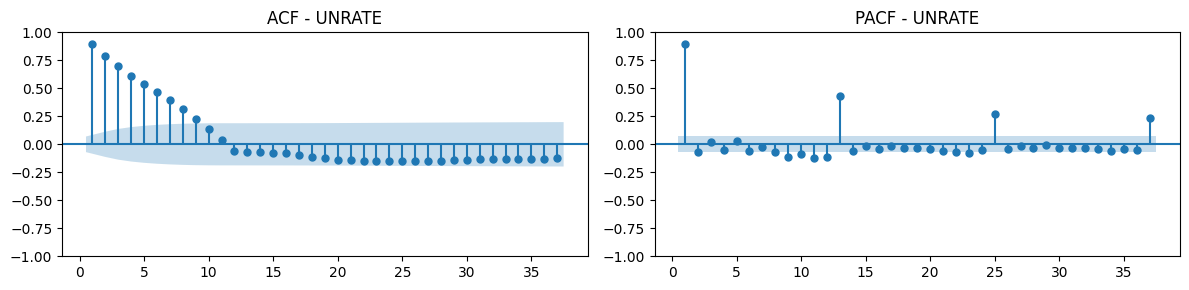

In [14]:
plot_acf_pacf_stationary(df[["UNRATE"]], lags=37)

## Règle d'interprétation
ACF : indique combien longtemps le passé influence le présent (mémoire).

PACF : indique quels retards comptent réellement (effet direct).


ACF qui décroît lentement → forte persistance

PACF avec quelques pics nets → dépendance concentrée sur peu de retards

Les corrélation décroissent lentement et restent significatives sur plusieurs lags. Pas de coupure nette, donc ce n'est pas un processus Moving Average. C'est typique d'un processus autorégressif persistant. 

Dans la réalité économique, celà veut dire que les chocs (crises, reprises) se dissipent lentement d'une manière générale. 

Pour PACF, un gros pic se situe au lag 1. çà montre donc une dépendance immédiate très forte. Un pic secondaire vient vers lag 12 et plus faiblement en lag 24 et 36. 

A part le lag 1 déjà essayé, la croissance du chômage de l'année dernière pourrait donc un bon anticipateur du chômage actuel.

## Est-ce que le nombre de retards significatifs à chaque année nous montre que le taux de chômage detient une saisonnalité ou cycle? 

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fourier_spectrum(
    y,
    *,
    freq=12,
    k=3,
    min_freq=0.05,
    title="Fourier Spectrum - UNRATE (stationary)",
):
    """
    Analyse fréquentielle via FFT avec annotation des k pics dominants.
    
    - k : nombre de pics spectraux à afficher
    - min_freq : ignore les très basses fréquences (résidu de trend)
    """
    y = y.dropna().values
    n = len(y)

    fft_vals = np.fft.fft(y)
    power = np.abs(fft_vals) ** 2
    freqs = np.fft.fftfreq(n, d=1 / freq)

    # fréquences positives utiles
    mask = freqs > min_freq
    freqs_pos = freqs[mask]
    power_pos = power[mask]

    # top-k pics spectraux
    idx = np.argsort(power_pos)[-k:][::-1]
    top_freqs = freqs_pos[idx]
    top_power = power_pos[idx]

    plt.figure(figsize=(10, 4))
    plt.plot(freqs_pos, power_pos, label="Spectrum")

    # références calendaires
    plt.axvline(1, color="r", linestyle="--", alpha=0.6, label="1 year")
    plt.axvline(1 / 2, color="gray", linestyle="--", alpha=0.4, label="2 years")
    plt.axvline(1 / 3, color="gray", linestyle="--", alpha=0.4, label="3 years")

    # annotation des pics dominants
    for f, p in zip(top_freqs, top_power):
        period = 1 / f
        plt.axvline(f, color="blue", linestyle=":", alpha=0.8)
        plt.text(
            f,
            p,
            f"{period:.1f} yrs",
            rotation=90,
            verticalalignment="bottom",
            horizontalalignment="right",
            fontsize=9,
            color="blue",
        )

    plt.xlabel("Cycles per year")
    plt.ylabel("Spectral power")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


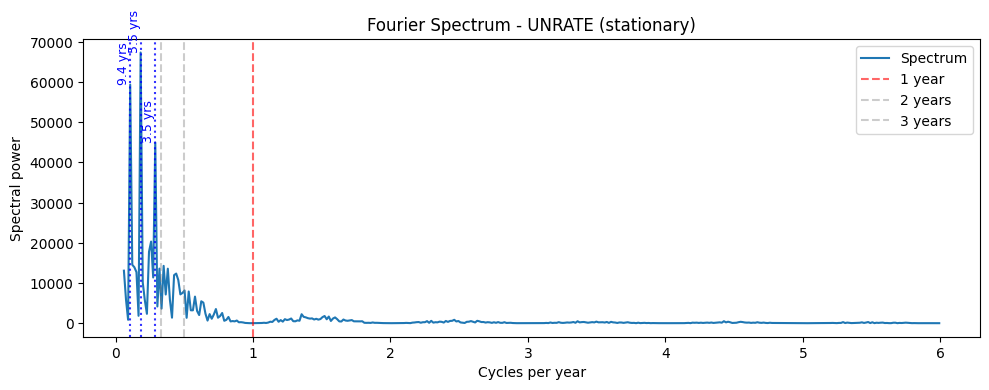

In [22]:
plot_fourier_spectrum(df["UNRATE"])

Le chômage ne montre pas une saisonnalité basse. Il essaye de nous dire par contre qu'un comportement se répète environ chaque 9 ans et demi. Il s'agit du cycle long de l'économie américaine. 

En effet, l'économie américaine a constaté une récession à partir de la moitié de l'année 1990. Une autre viendra au début du 21è siècle avec l'évènement de ... 

La crise de Subprimes vient un peu plus rapidement avec un décalage de 8 années par rapport à la dernière récession. 

La crise de Covid-19 arrive 11 ans plus tard.

Du point de vue de modélisation, ce graphique confirme notre analyse d'analyser l'économie américaine par ces périodes, par cycle. 

Il est plus facile de trouver les variables explicatives dans l'approche traditionnelle. Il suffit juste de sélectionner les variables avec des techniques comme ACP, régularisation LASSO, etc.

Le plus grand problème cependant, dès sélectionne nos variables sur ces techniques, on empêche notre expérimentation de trouver éventuellement des relations non linéaires. Puisque ces techniques de sélection elles-mêmes sont fondées sur l'hypothèse de linéarité. 

Notre stratégie de sélection de variables se basent donc la confrontation des théories économiques, l'histoire des Etats-Unis et les données. 

Vous pourriez vous demander s’il faut sélectionner les variables une à une.
Dans un premier temps, nous procédons à une sélection manuelle d’un nombre restreint de variables (environ une dizaine), sur lesquelles repose la première phase d’expérimentation.

Dans un second temps, l’ensemble des variables est injecté dans le processus expérimental. Les modèles linéaires assurent alors une sélection des variables pertinentes d’un point de vue linéaire, tandis que les modèles de Machine Learning permettent de capturer des relations non linéaires entre les variables.

L’objectif est d’analyser si ces deux approches convergent vers des résultats similaires, ou si la seconde phase met en évidence des variables ou des dynamiques jusqu’alors non prises en compte.

# Crisis

In [23]:
import pandas as pd

# Série USREC (index = date, valeur = 0/1)
usrec = df["USREC"].copy()

# Détection des débuts et fins de crise
crisis_start = (usrec == 1) & (usrec.shift(1) == 0)
crisis_end   = (usrec == 1) & (usrec.shift(-1) == 0)

# Table des périodes de crise
crises = pd.DataFrame({
    "start": usrec.index[crisis_start],
    "end": usrec.index[crisis_end]
})

# Durée en mois
crises["duration_months"] = (
    (crises["end"].dt.to_period("M") - crises["start"].dt.to_period("M"))
    .apply(lambda x: x.n + 1)
)

crises

C:\Users\Mita\AppData\Local\Temp\ipykernel_11864\1339061582.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  (crises["end"].dt.to_period("M") - crises["start"].dt.to_period("M"))


,start,end,duration_months
0,1960-05-01 00:00:00+00:00,1961-02-01 00:00:00+00:00,10
1,1970-01-01 00:00:00+00:00,1970-11-01 00:00:00+00:00,11
2,1973-12-01 00:00:00+00:00,1975-03-01 00:00:00+00:00,16
3,1980-02-01 00:00:00+00:00,1980-07-01 00:00:00+00:00,6
4,1981-08-01 00:00:00+00:00,1982-11-01 00:00:00+00:00,16
5,1990-08-01 00:00:00+00:00,1991-03-01 00:00:00+00:00,8
6,2001-04-01 00:00:00+00:00,2001-11-01 00:00:00+00:00,8
7,2008-01-01 00:00:00+00:00,2009-06-01 00:00:00+00:00,18
8,2020-03-01 00:00:00+00:00,2020-04-01 00:00:00+00:00,2


In [24]:
import plotly.graph_objects as go

# ----------------------------
# 1) Données
# ----------------------------
mid_dates = crises["start"] + (crises["end"] - crises["start"]) / 2
top3_idx = crises["duration_months"].nlargest(3).index

colors = ["red" if i in top3_idx else "gray" for i in crises.index]
sizes = crises["duration_months"] * 40

crisis_names = {
    "1960-05-01": "Récession 1960–61",
    "1970-01-01": "Récession 1970",
    "1973-12-01": "Choc pétrolier 1973–75",
    "1980-02-01": "Récession 1980",
    "1981-08-01": "Récession 1981–82",
    "1990-08-01": "Récession 1990–91",
    "2001-03-01": "Crise Internet (dot-com)",
    "2007-12-01": "Crise des subprimes",
    "2020-02-01": "Crise du Covid-19",
}

# ----------------------------
# 2) Hover uniquement
# ----------------------------
descriptions = []
for i, row in crises.iterrows():
    start_str = row["start"].strftime("%Y-%m")
    end_str = row["end"].strftime("%Y-%m")
    key = row["start"].strftime("%Y-%m-%d")
    name = crisis_names.get(key, "Crise économique")

    top_tag = " (TOP 3)" if i in top3_idx else ""
    descriptions.append(
        f"<b>{name}</b>{top_tag}<br>"
        f"Période : {start_str} → {end_str}<br>"
        f"Durée : {row['duration_months']} mois"
    )

# ----------------------------
# 3) Plot
# ----------------------------
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=mid_dates,
        y=[1] * len(crises),
        mode="markers",  # ✅ PAS de texte affiché
        marker=dict(size=sizes, color=colors, opacity=0.85, sizemode="area"),
        hovertext=descriptions,  # ✅ texte seulement au survol
        hovertemplate="%{hovertext}<extra></extra>",
        showlegend=False,
    )
)

fig.update_layout(
    title="Crises US : timing et durée (top 3 en rouge)",
    xaxis_title="Année",
    yaxis=dict(visible=False, range=[0.9, 1.1]),
    template="plotly_dark",
    height=420,
    width=900,
)

fig.show()

En termes de durrée, les trois crises les plus persistantes Etats-Unis après 1960 sont : 
- les deux premiers chocs pétroliers (70s et 80s) ; 
- La crise de Subprime de 2008 ; 
- La crise de Coronavirus (2020) a été très vite résorbée par l'économie.

La crise de pétrole signifie baisse drastique du cours du pétrol. Nous devrons donc tenir en compte du prix du baril du pétrol dans nos modèles. Il capte les chocs centraux globaux. Si le chômage est liée à l'indicateur de récession (voir analyse bivariée).

La crise des subprimes correspond à une rupture du canal du crédit. La dégradation des prêts a provoqué un credit crunch. Normalement, celà freine l’investissement et la consommation. Cet effet multiplicateur entraine la persistance de la dégradation de la performance économique. 

Le BUSLOANS est donc une variable très important dans nos expérimentations. 

# Conclusion

Voici donc les variables qui ressortent immédiatement de nos analyses de crise : 
- prix de baril du pétrol ; 
- Crédit bancaire aux entreprises ;

Il faut faire une analyse bivariée de la relation entre taux de chômage et récession. 

# Analyse de l'unité des valeurs

In [15]:
import pandas as pd
import plotly.graph_objects as go

# ----------------------------
# 1) Sélection des variables
# ----------------------------
df_plot = df.copy()
df_plot.index = pd.to_datetime(df_plot.index)

# garder uniquement les colonnes numériques
num_cols = df_plot.select_dtypes(include="number").columns.tolist()

# retirer USREC s’il existe
num_cols = [c for c in num_cols if c != "USREC"]

# ----------------------------
# 2) Heuristique axes Y
#    - taux (%) → axe gauche
#    - niveaux / indices → axe droit
# ----------------------------
left_axis_vars = [c for c in num_cols if c in ["UNRATE", "TB3MS"]]
right_axis_vars = [c for c in num_cols if c not in left_axis_vars]

# ----------------------------
# 3) Figure
# ----------------------------
fig = go.Figure()

# Axe gauche (taux)
for col in left_axis_vars:
    fig.add_trace(
        go.Scatter(
            x=df_plot.index,
            y=df_plot[col],
            mode="lines",
            name=col,
            line=dict(width=3),
            yaxis="y",
        )
    )

# Axe droit (niveaux)
for col in right_axis_vars:
    fig.add_trace(
        go.Scatter(
            x=df_plot.index,
            y=df_plot[col],
            mode="lines",
            name=col,
            line=dict(width=2),
            opacity=0.85,
            yaxis="y2",
        )
    )

# ----------------------------
# 4) Layout
# ----------------------------
fig.update_layout(
    title="Séries macroéconomiques – unités réelles (sans normalisation)",
    xaxis_title="Année",
    yaxis=dict(
        title="Taux (%)",
        showgrid=True,
    ),
    yaxis2=dict(
        title="Niveaux / indices",
        overlaying="y",
        side="right",
        showgrid=False,
    ),
    template="plotly_dark",
    height=540,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1,
    ),
)

fig.show()

# Principe
Normalement, les variables différenciées à second ordre ont une amplitude plus faible et semblable. Elles seront suivies par les variables différenciées de 1er ordre et celles différenciées à niveau. 

# Différence de 2nd ordre
Les variables différenciées de second ordre relève de la sphère monétaire : l'offre monétaire, l'inflation et le crédit bancaire aux entreprises. 
On constate réellement qu'ils suivent un comportement pareil avec un changement brusque en 2019. OilPrice est une exception dans ce groupe. Je pense qu'à cause de grande volatilité (cf. graphique ci-dessous)

# Différence de 1er ordre
Dans le log 1, il n'y a pas une grande différence avec le 2nd ordre quand on parle de l'évolution de : 
- Revenu ; 
- Consommation ; 
- Production industrielle.
La sphère réelle n'est pas aussi volatile. 
Dans la sphère financière par contre, le SP500 se comporte différement. 

# Différence à niveau 
Le taux TB3MS n'a pas la même moyenne que toutes les variables avec une volatilité accrue durant la crise de 2008. 
Le taux de chômage fait partie de cette tendance. 